An undergraduate project on crop selection prediction using Feedfoward Neural network. 
    

# WEATHER DATA

In [2]:
# Libraries importation
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import shap
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim 
import table_evaluator

from scipy.stats.mstats import winsorize 
from ctgan import CTGAN
from numpy import interp
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
 
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Importing the data
weather_df = pd.read_csv(r"C:\Users\DELL\Deployment\final_year_project\Weather.csv")

In [4]:
# To check the first 5 rows
weather_df.head()

,Year,T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m
0,2010,33.55,14.20,0.0,26.13,2.92
1,2010,33.37,13.49,0.0,23.75,3.11
2,2010,32.23,12.44,0.0,22.46,3.36
3,2010,32.74,12.34,0.0,25.80,1.91
4,2010,32.37,13.90,0.0,30.21,1.67


In [5]:
# To check the details about the data
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5845 entries, 0 to 5844
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   5845 non-null   int64  
 1   T2m_Max                5845 non-null   float64
 2   T2m_Min                5845 non-null   float64
 3   Precipitation          5845 non-null   float64
 4   Relative_humidity_2_m  5845 non-null   float64
 5   Wind_speed_2_m         5845 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 274.1 KB


In [6]:
# Looking for missing values
missing_values = weather_df.isna().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [7]:
# Checking for duplicates
weather_df.duplicated().sum()

0

Yes, daily precipitation can be 0.0 mm (0.0 inches) in Kaduna North, particularly during the dry season which lasts for about 6.4 months, when rain don't fall.

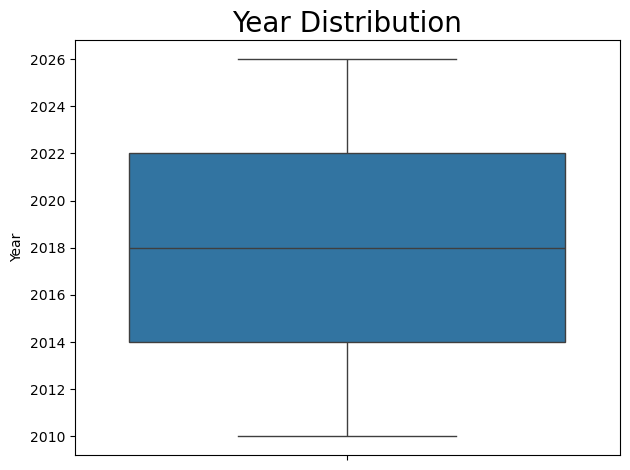

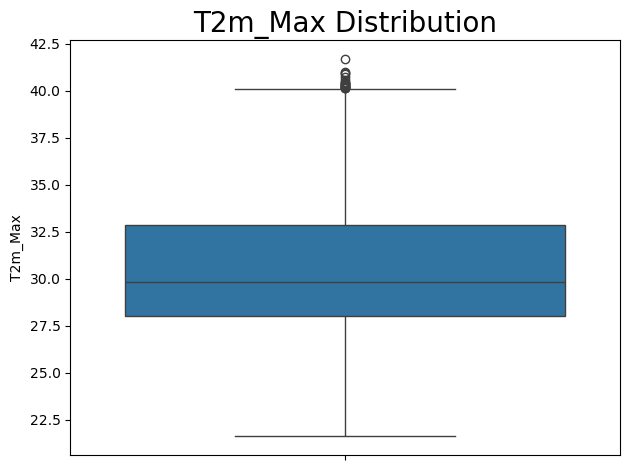

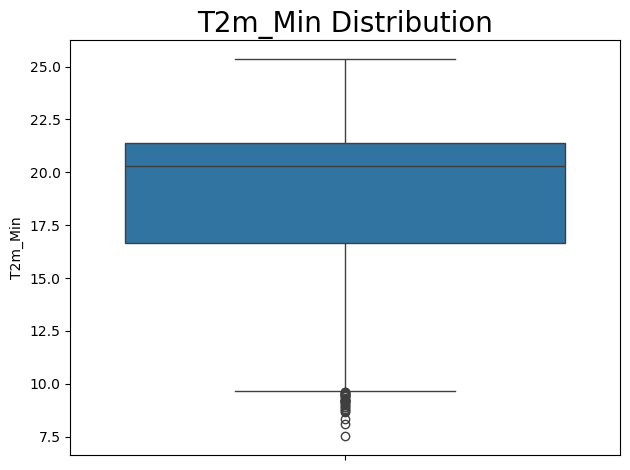

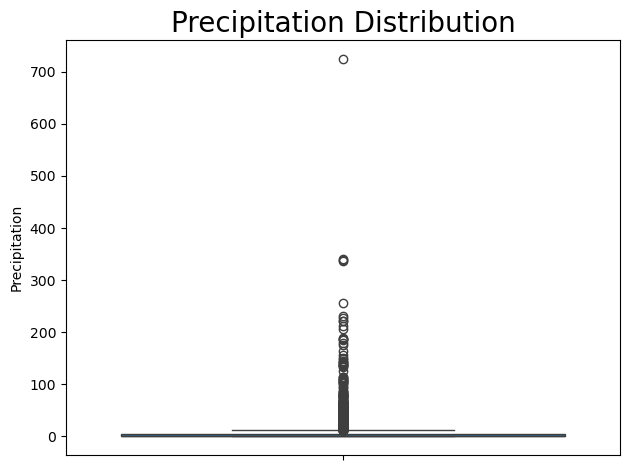

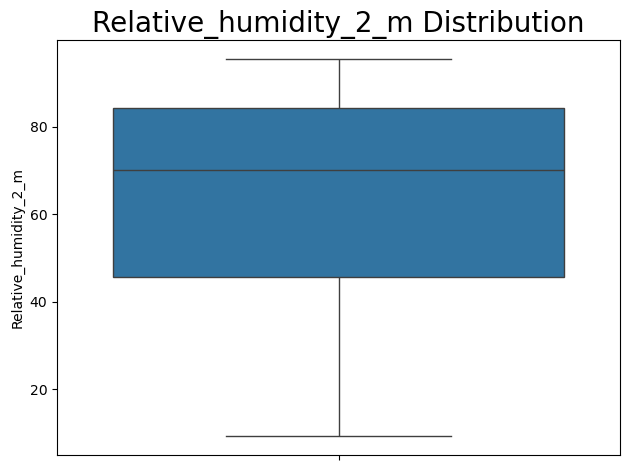

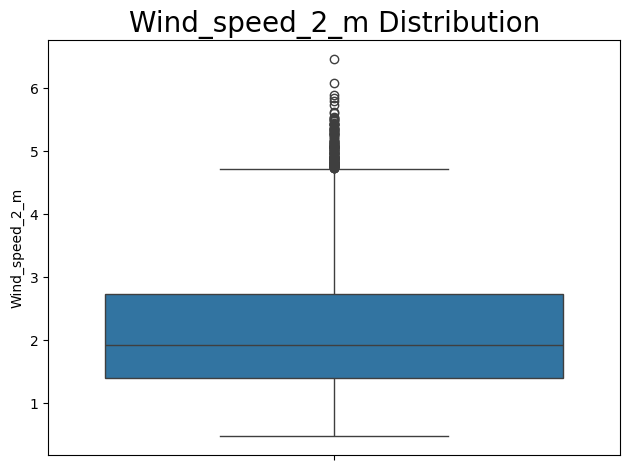

In [8]:
# Looking for outliers
for col in weather_df.columns:
    sns.boxplot(weather_df[col], orient = 'x')
    plt.title(f'{col} Distribution', fontsize = 20, y = 1.0)
    plt.tight_layout()
    plt.show()

In [9]:
for col in ['T2m_Max', 'T2m_Min', 'Precipitation', 'Wind_speed_2_m']:
    weather_df[col] = winsorize(weather_df[col], limits = [0.05, 0.05])

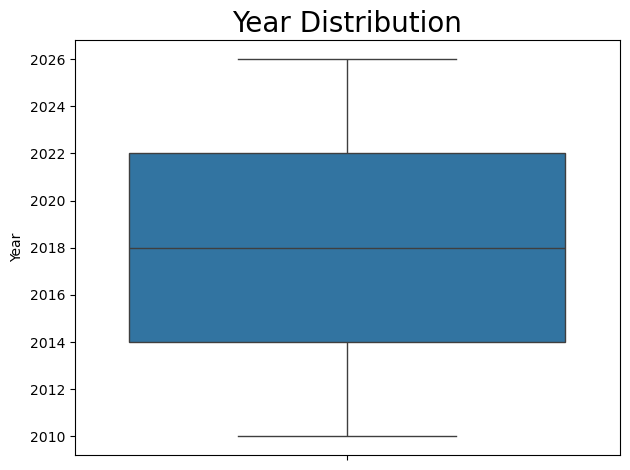

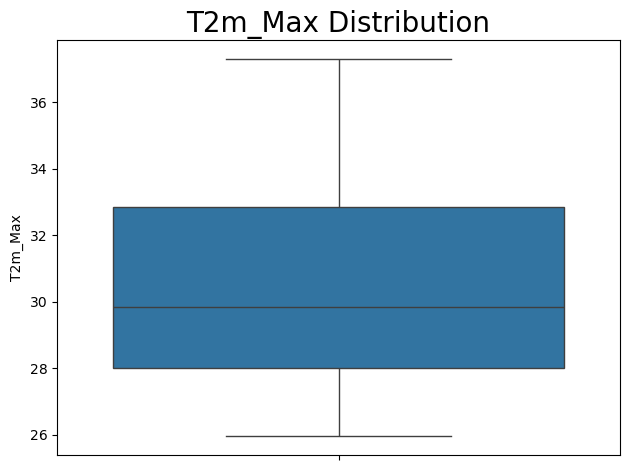

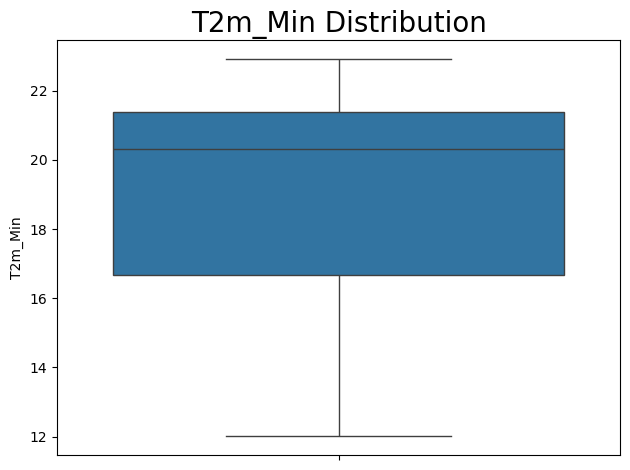

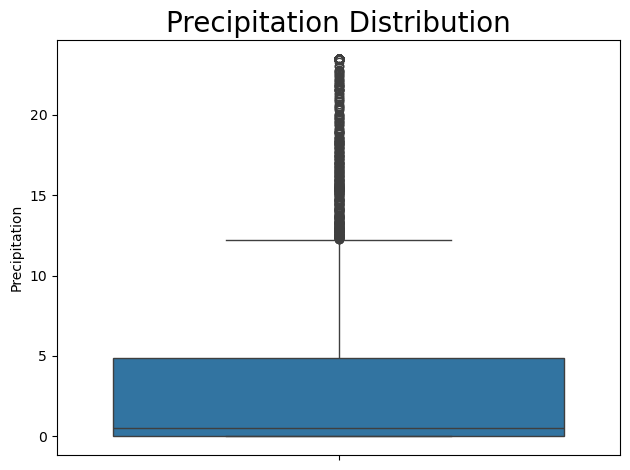

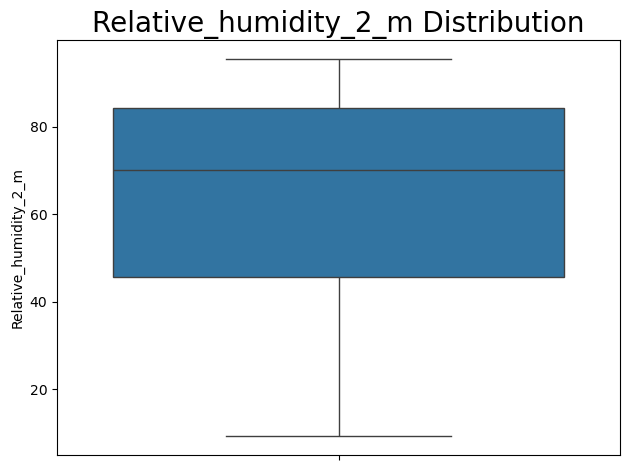

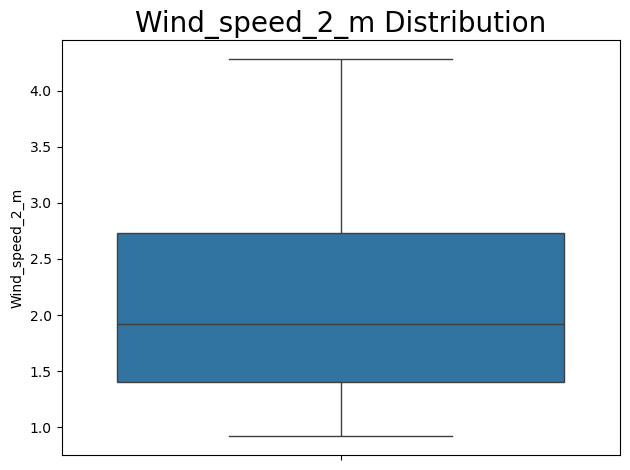

In [10]:
for col in weather_df.columns:
    sns.boxplot(weather_df[col], orient = 'x')
    plt.title(f'{col} Distribution', fontsize = 20, y = 1.0)
    plt.tight_layout()
    plt.show()

In [11]:
weather_df['Precipitation'] = winsorize(weather_df['Precipitation'], limits = [0.15, 0.15])

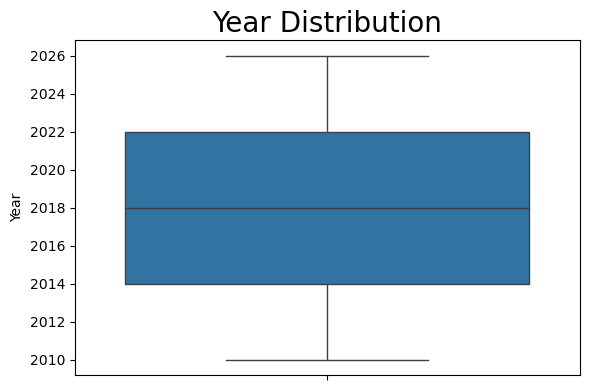

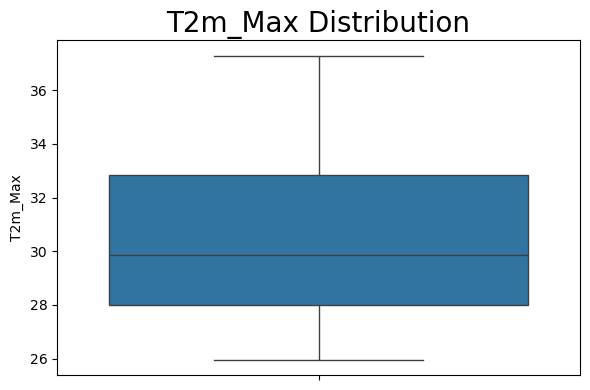

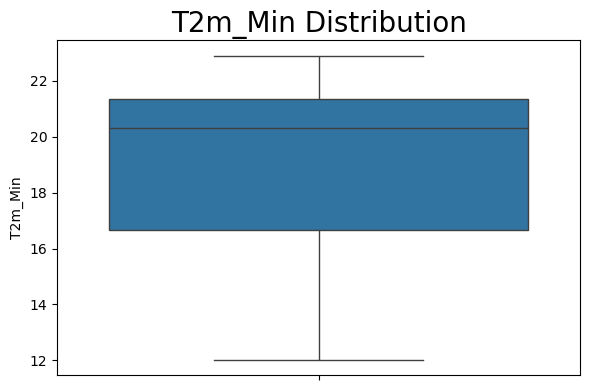

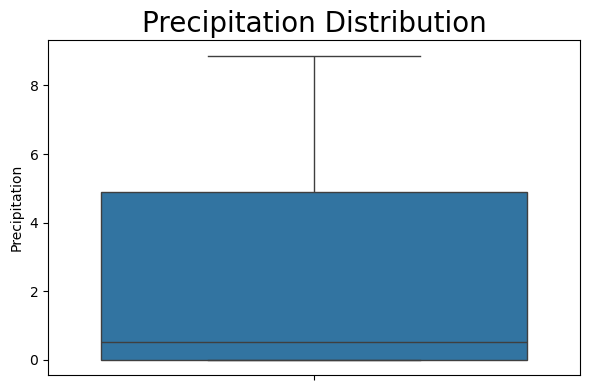

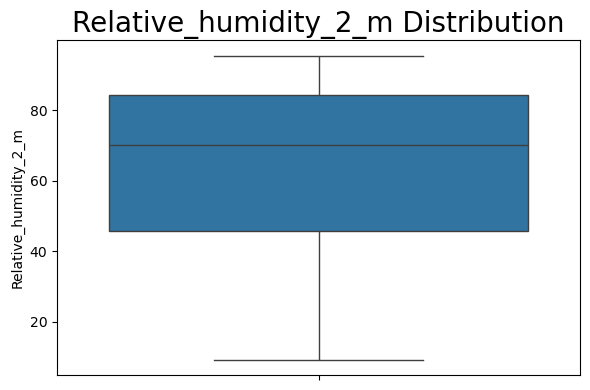

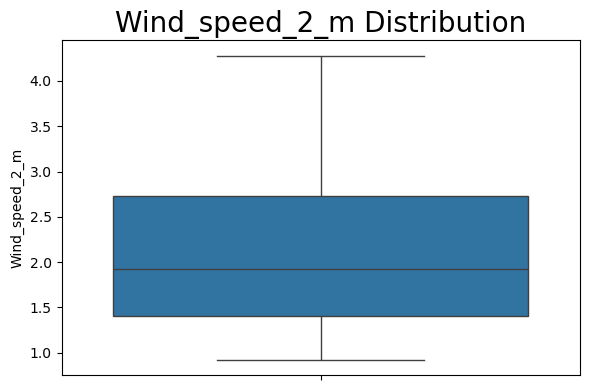

In [12]:
for col in weather_df.columns:
    plt.figure(figsize = (6, 4))
    sns.boxplot(weather_df[col], orient = 'x')
    plt.title(f'{col} Distribution', fontsize = 20, y = 1.0)
    plt.tight_layout()
    plt.show()

In [13]:
weather_df.describe()

,Year,T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m
count,5845.000000,5845.000000,5845.000000,5845.000000,5845.000000,5845.000000
mean,2017.501796,30.586821,19.005141,2.638881,64.147406,2.154364
std,4.611038,3.289785,3.262933,3.384170,22.488362,0.958824
min,2010.000000,25.950000,12.010000,0.000000,9.190000,0.920000
25%,2014.000000,28.000000,16.680000,0.000000,45.580000,1.400000
50%,2018.000000,29.850000,20.300000,0.510000,70.140000,1.920000
75%,2022.000000,32.850000,21.370000,4.900000,84.290000,2.730000
max,2026.000000,37.290000,22.910000,8.870000,95.430000,4.280000


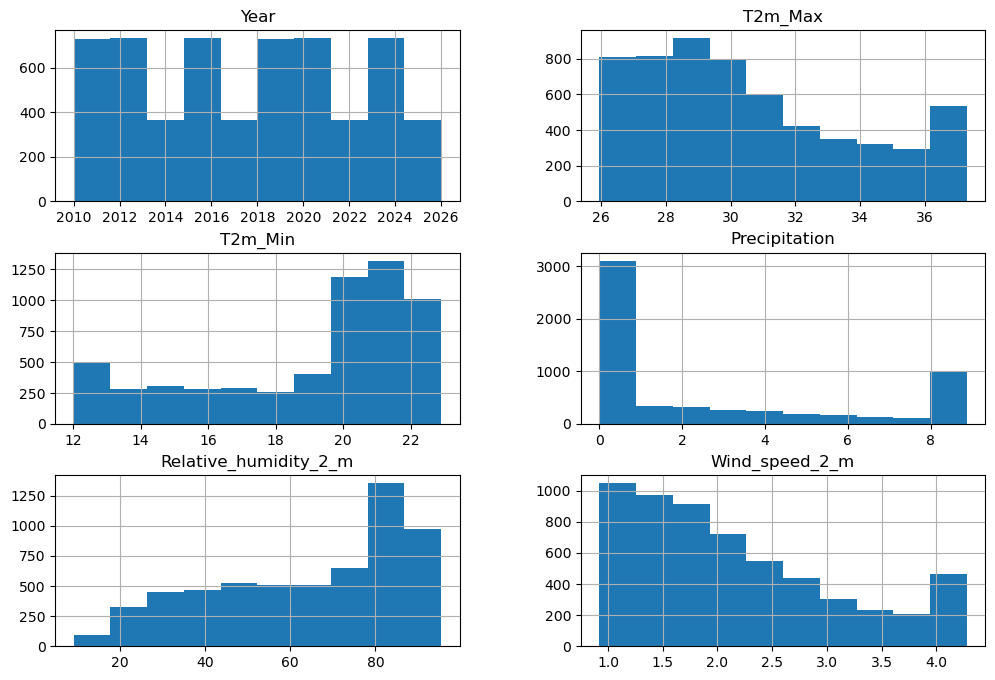

In [14]:
weather_df.hist(figsize = (12,8))
plt.show()

In [15]:
# Log Transformation for the skewed column
weather_df["Precipitation_log"] = np.log1p(weather_df["Precipitation"])

In [16]:
df_yearly = weather_df.groupby("Year").agg({
    "T2m_Max": "mean", "T2m_Min": "mean",
    "Precipitation": "sum","Relative_humidity_2_m": "mean", 
    "Wind_speed_2_m": "mean"}).reset_index()

In [17]:
df_yearly

,Year,T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m
0,2010,31.085534,19.600603,1014.43,62.411205,2.135041
1,2011,31.282904,18.792740,897.02,59.460603,2.172685
2,2012,30.363388,18.925301,1259.25,63.799098,2.139180
3,2013,31.604110,19.352795,684.01,62.167260,2.011836
4,2014,31.558932,19.624356,958.62,59.349397,2.117370
5,2015,31.135068,19.172575,900.97,58.344685,2.339781
6,2016,30.292240,18.972432,1034.39,65.996093,2.067049
7,2017,30.567014,18.884301,953.76,63.010082,2.134411
8,2018,30.523425,18.987945,945.19,64.491233,2.069370
9,2019,30.790329,19.322493,924.55,63.853096,2.090603


Why did i aggregate this way?

Because:

Rainfall accumulates so it must sum

Temperature describes climate  mean is meaningful

Soil wetness reflects seasonal moisture  mean works

In [18]:
df_yearly.head(10)

,Year,T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m
0,2010,31.085534,19.600603,1014.43,62.411205,2.135041
1,2011,31.282904,18.792740,897.02,59.460603,2.172685
2,2012,30.363388,18.925301,1259.25,63.799098,2.139180
3,2013,31.604110,19.352795,684.01,62.167260,2.011836
4,2014,31.558932,19.624356,958.62,59.349397,2.117370
5,2015,31.135068,19.172575,900.97,58.344685,2.339781
6,2016,30.292240,18.972432,1034.39,65.996093,2.067049
7,2017,30.567014,18.884301,953.76,63.010082,2.134411
8,2018,30.523425,18.987945,945.19,64.491233,2.069370
9,2019,30.790329,19.322493,924.55,63.853096,2.090603



My dataset contains **5,845 weather records from 2010 to 2026**, including maximum temperature, minimum temperature, precipitation (rainfall), relative humidity, and wind speed. Most of the variables, such as temperature and wind speed, are fairly balanced because their **mean and median values are close**, which suggests the data is approximately normally distributed.

However, **precipitation is slightly right-skewed**. This means that **many days have little or no rainfall**,
while **a few days have very high rainfall values**. Because of these few large values, the distribution 
stretches toward the **right side**, which increases the mean compared to the median. 
This type of pattern is very common in weather data.

To understand skewness:

* **Right-skewed (positive skew)**: Most values are small, with a few very large values pulling 
the distribution toward the **right**.
* **Left-skewed (negative skew)**: Most values are large, with a few very small values pulling 
the distribution toward the **left**.

Overall, the dataset is still **valid and suitable for analysis and machine learning**, 
since skewness like this is normal in environmental and climate data.


# YIELD DATA

In [19]:
yield_df = pd.read_csv(r"C:\Users\DELL\Deployment\final_year_project\KADA_CROP2.csv")

In [20]:
yield_df.head()

,Crop,Year,Area (hectares),Yield,Output (tonnes)
0,Cassava,2011,39669.22,8.00,317353.75
1,Yam,2011,65974.96,8.27,471338.31
2,Cocoyam,2011,1469.57,5.00,7347.83
3,Sweet potato,2011,11494.62,9.58,110172.07
4,Maize,2011,388189.90,1.86,720924.11


In [21]:
yield_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             104 non-null    object 
 1   Year             104 non-null    int64  
 2   Area (hectares)  104 non-null    float64
 3   Yield            103 non-null    float64
 4   Output (tonnes)  103 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 4.2+ KB


In [22]:
missing = yield_df.isna().sum()
missing[missing > 0]

Yield              1
Output (tonnes)    1
dtype: int64

In [23]:
# Impute missing Yield based on the specific Crop's average
yield_df["Yield"] = yield_df.groupby("Crop")["Yield"].transform(lambda x: x.fillna(x.mean()))

In [24]:

# Impute missing Output based on the specific Crop's average
yield_df["Output (tonnes)"] = yield_df.groupby("Crop")["Output (tonnes)"].transform(lambda x: x.fillna(x.mean()))

In [25]:
yield_df.duplicated().sum()

0

In [26]:
yield_df["Crop"].unique()

array(['Cassava', 'Yam', 'Cocoyam', 'Sweet potato', 'Maize', 'Sorghum',
       'Rice', 'Ground nut', 'Cowpea', 'Soyabean', 'Tomato', 'Onion',
       'Cotton', 'Ginger', 'Sugar cane', 'Pepper', 'Acha', 'Millet',
       'Garden egg', 'Okra'], dtype=object)

In [27]:
yield_weather_df = pd.merge(yield_df, df_yearly, on = "Year", how = "left")

In [28]:
yield_weather_df.head(5)

,Crop,Year,Area (hectares),Yield,Output (tonnes),T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m
0,Cassava,2011,39669.22,8.00,317353.75,31.282904,18.79274,897.02,59.460603,2.172685
1,Yam,2011,65974.96,8.27,471338.31,31.282904,18.79274,897.02,59.460603,2.172685
2,Cocoyam,2011,1469.57,5.00,7347.83,31.282904,18.79274,897.02,59.460603,2.172685
3,Sweet potato,2011,11494.62,9.58,110172.07,31.282904,18.79274,897.02,59.460603,2.172685
4,Maize,2011,388189.90,1.86,720924.11,31.282904,18.79274,897.02,59.460603,2.172685


In [29]:
yield_weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Crop                   104 non-null    object 
 1   Year                   104 non-null    int64  
 2   Area (hectares)        104 non-null    float64
 3   Yield                  104 non-null    float64
 4   Output (tonnes)        104 non-null    float64
 5   T2m_Max                104 non-null    float64
 6   T2m_Min                104 non-null    float64
 7   Precipitation          104 non-null    float64
 8   Relative_humidity_2_m  104 non-null    float64
 9   Wind_speed_2_m         104 non-null    float64
dtypes: float64(8), int64(1), object(1)
memory usage: 8.2+ KB


# SOIL AND WEATHER DATA

In [30]:
np.random.seed(42)
samples = len(yield_weather_df)

# Water source distribution
water_sources = ["Rainfed", "Irrigation", "Borehole"]
water_probs = [0.6, 0.3, 0.1]
Water_Source = np.random.choice(water_sources, size = samples, p = water_probs)

In [31]:
Distance_to_Water_km = []

for source in Water_Source:
    
    # Distance depends on water source
    if source == "Rainfed":
        Distance_to_Water_km.append(np.random.uniform(3, 10))
        
    elif source == "Irrigation":
        Distance_to_Water_km.append(np.random.uniform(0.5, 3))
        
    else:  # Borehole
        Distance_to_Water_km.append(np.random.uniform(0.5, 5))

Distance_to_Water_km = np.array(Distance_to_Water_km)

In [32]:
# Soil moisture depends on water source
Soil_Moisture = []

for source in Water_Source:
    if source == "Rainfed":
        Soil_Moisture.append(np.random.normal(22, 6))
    elif source == "Irrigation":
        Soil_Moisture.append(np.random.normal(35, 5))
    else:
        Soil_Moisture.append(np.random.normal(30, 6))

Soil_Moisture = np.clip(Soil_Moisture, 5, 50)

# Semi-independent soil chemistry
Soil_pH = np.clip(np.random.normal(6.2, 0.4, samples), 5.0, 7.5)
Nitrogen = np.clip(np.random.normal(35, 10, samples), 10, 70)
Phosphorus = np.clip(np.random.normal(20, 7, samples), 5, 50)
Potassium = np.clip(np.random.normal(150, 30, samples), 80, 250)
Organic_Matter = np.clip(np.random.normal(2.5, 0.7, samples), 0.5, 5)

In [33]:
soil_water_df = pd.DataFrame({
    "Soil_pH": Soil_pH,
    "Nitrogen_mgkg": Nitrogen,
    "Phosphorus_mgkg": Phosphorus,
    "Potassium_mgkg": Potassium,
    "Organic_Matter_%": Organic_Matter,
    "Soil_Moisture_%": Soil_Moisture,
    "Distance_to_Water_km": Distance_to_Water_km,
    "Water_Source": Water_Source
})

In [34]:
soil_water_df.head()

,Soil_pH,Nitrogen_mgkg,Phosphorus_mgkg,Potassium_mgkg,Organic_Matter_%,Soil_Moisture_%,Distance_to_Water_km,Water_Source
0,5.829228,41.901440,16.286492,159.807821,1.722597,33.194647,9.352965,Rainfed
1,6.176190,30.987795,15.969272,143.426984,3.726589,32.842998,1.621815,Borehole
2,5.000000,37.240925,18.074638,174.882167,3.154975,29.043483,1.525957,Irrigation
3,5.790245,35.125924,5.000000,83.665941,3.390089,25.939322,8.288858,Rainfed
4,6.098973,35.976761,9.393663,157.068437,3.005170,16.151910,4.601587,Rainfed


In [35]:
# Reset indices before concatenation to ensure row alignment
yield_weather_df.reset_index(drop = True, inplace = True)
soil_water_df.reset_index(drop = True, inplace = True)

In [36]:
# Concatenate the dataframes horizontally
full_df = pd.concat([yield_weather_df, soil_water_df], axis = 1)

In [37]:
full_df.head()

,Crop,Year,Area (hectares),Yield,Output (tonnes),T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m,Soil_pH,Nitrogen_mgkg,Phosphorus_mgkg,Potassium_mgkg,Organic_Matter_%,Soil_Moisture_%,Distance_to_Water_km,Water_Source
0,Cassava,2011,39669.22,8.00,317353.75,31.282904,18.79274,897.02,59.460603,2.172685,5.829228,41.901440,16.286492,159.807821,1.722597,33.194647,9.352965,Rainfed
1,Yam,2011,65974.96,8.27,471338.31,31.282904,18.79274,897.02,59.460603,2.172685,6.176190,30.987795,15.969272,143.426984,3.726589,32.842998,1.621815,Borehole
2,Cocoyam,2011,1469.57,5.00,7347.83,31.282904,18.79274,897.02,59.460603,2.172685,5.000000,37.240925,18.074638,174.882167,3.154975,29.043483,1.525957,Irrigation
3,Sweet potato,2011,11494.62,9.58,110172.07,31.282904,18.79274,897.02,59.460603,2.172685,5.790245,35.125924,5.000000,83.665941,3.390089,25.939322,8.288858,Rainfed
4,Maize,2011,388189.90,1.86,720924.11,31.282904,18.79274,897.02,59.460603,2.172685,6.098973,35.976761,9.393663,157.068437,3.005170,16.151910,4.601587,Rainfed


In [38]:
full_df.drop(columns = ["Year", "Area (hectares)", "Yield", "Output (tonnes)"], inplace = True)

In [39]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Crop                   104 non-null    object 
 1   T2m_Max                104 non-null    float64
 2   T2m_Min                104 non-null    float64
 3   Precipitation          104 non-null    float64
 4   Relative_humidity_2_m  104 non-null    float64
 5   Wind_speed_2_m         104 non-null    float64
 6   Soil_pH                104 non-null    float64
 7   Nitrogen_mgkg          104 non-null    float64
 8   Phosphorus_mgkg        104 non-null    float64
 9   Potassium_mgkg         104 non-null    float64
 10  Organic_Matter_%       104 non-null    float64
 11  Soil_Moisture_%        104 non-null    float64
 12  Distance_to_Water_km   104 non-null    float64
 13  Water_Source           104 non-null    object 
dtypes: float64(12), object(2)
memory usage: 11.5+ KB


In [40]:
save_path = r"C:\Users\DELL\Deployment\final_year_project\kaduna_crop_dataset.csv"
full_df.to_csv(save_path, index = False)

print("Dataset successfully saved!")
print("Location:", save_path)

Dataset successfully saved!
Location: C:\Users\DELL\Deployment\final_year_project\kaduna_crop_dataset.csv


# WORKING WITH ALL CONMBINED DATA

In [41]:
full_df.head()

,Crop,T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m,Soil_pH,Nitrogen_mgkg,Phosphorus_mgkg,Potassium_mgkg,Organic_Matter_%,Soil_Moisture_%,Distance_to_Water_km,Water_Source
0,Cassava,31.282904,18.79274,897.02,59.460603,2.172685,5.829228,41.901440,16.286492,159.807821,1.722597,33.194647,9.352965,Rainfed
1,Yam,31.282904,18.79274,897.02,59.460603,2.172685,6.176190,30.987795,15.969272,143.426984,3.726589,32.842998,1.621815,Borehole
2,Cocoyam,31.282904,18.79274,897.02,59.460603,2.172685,5.000000,37.240925,18.074638,174.882167,3.154975,29.043483,1.525957,Irrigation
3,Sweet potato,31.282904,18.79274,897.02,59.460603,2.172685,5.790245,35.125924,5.000000,83.665941,3.390089,25.939322,8.288858,Rainfed
4,Maize,31.282904,18.79274,897.02,59.460603,2.172685,6.098973,35.976761,9.393663,157.068437,3.005170,16.151910,4.601587,Rainfed


In [42]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Crop                   104 non-null    object 
 1   T2m_Max                104 non-null    float64
 2   T2m_Min                104 non-null    float64
 3   Precipitation          104 non-null    float64
 4   Relative_humidity_2_m  104 non-null    float64
 5   Wind_speed_2_m         104 non-null    float64
 6   Soil_pH                104 non-null    float64
 7   Nitrogen_mgkg          104 non-null    float64
 8   Phosphorus_mgkg        104 non-null    float64
 9   Potassium_mgkg         104 non-null    float64
 10  Organic_Matter_%       104 non-null    float64
 11  Soil_Moisture_%        104 non-null    float64
 12  Distance_to_Water_km   104 non-null    float64
 13  Water_Source           104 non-null    object 
dtypes: float64(12), object(2)
memory usage: 11.5+ KB


In [43]:
full_df.duplicated().sum()

0

In [44]:
full_num_cols = full_df.select_dtypes(["int", "float"]).columns

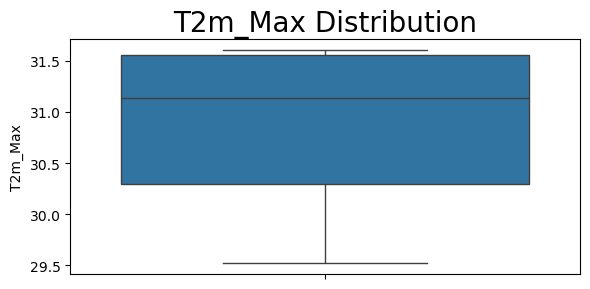

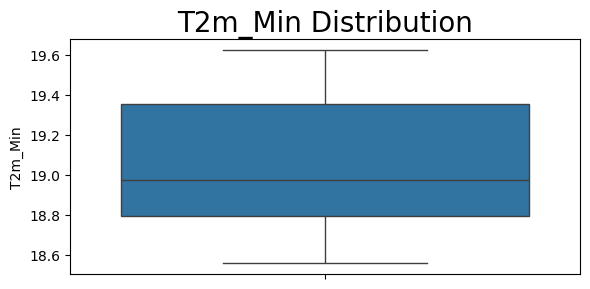

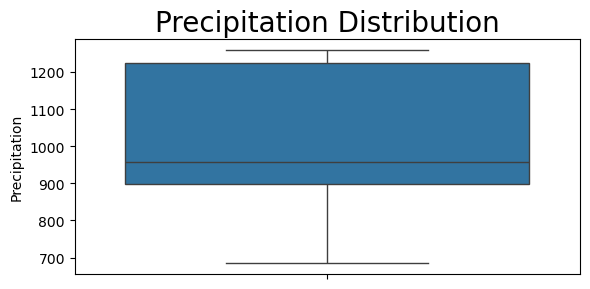

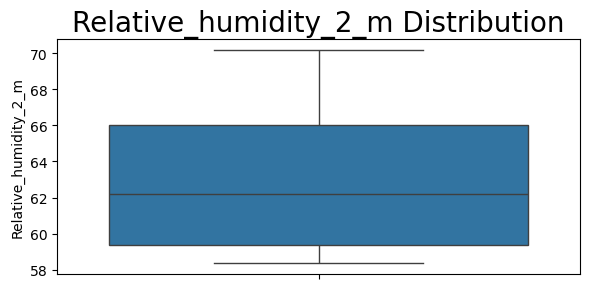

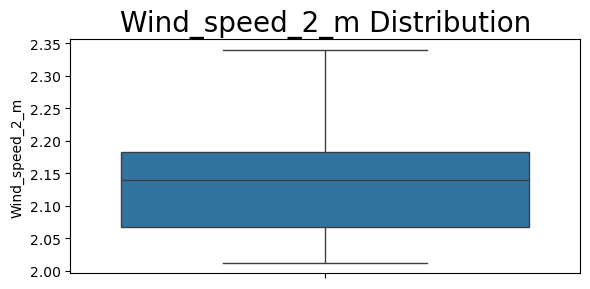

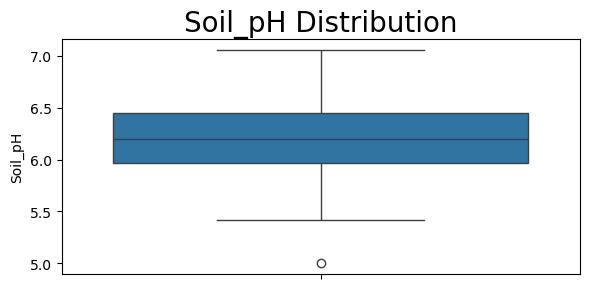

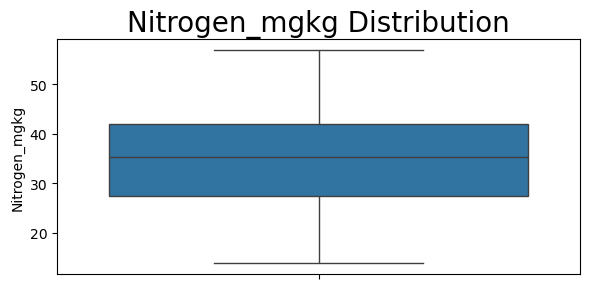

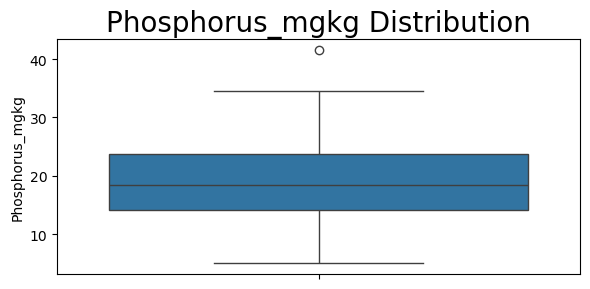

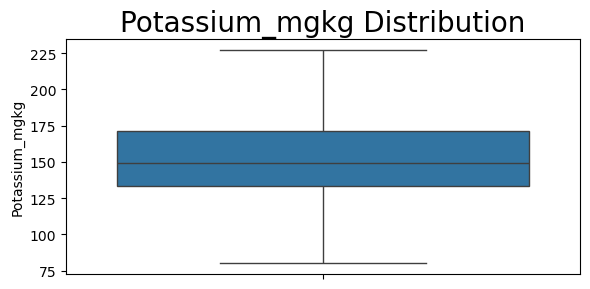

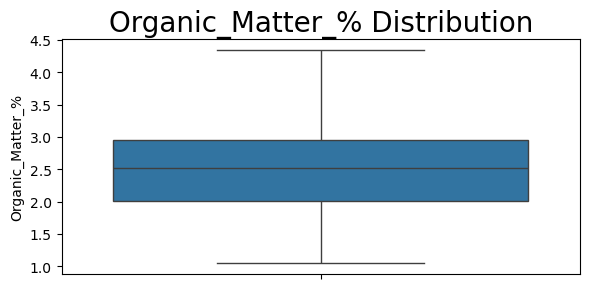

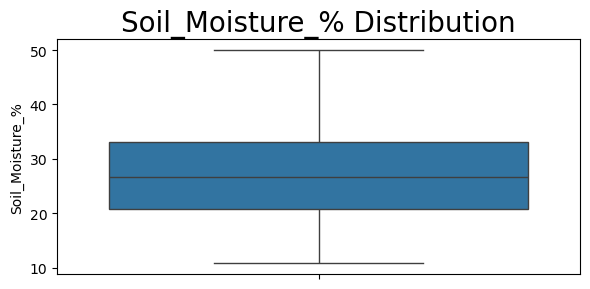

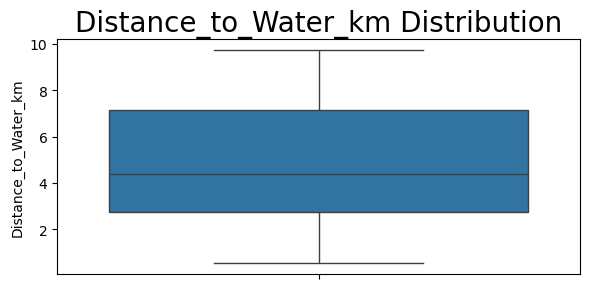

In [45]:
for col in full_num_cols:
    plt.figure(figsize = (6, 3))
    sns.boxplot(full_df[col], orient = 'X')
    plt.title(f'{col} Distribution', fontsize = 20, y = 1.0)
    plt.tight_layout()
    plt.show()

In [46]:
for col in full_num_cols:
    full_df[col] = winsorize(full_df[col], limits = [0.05, 0.05])

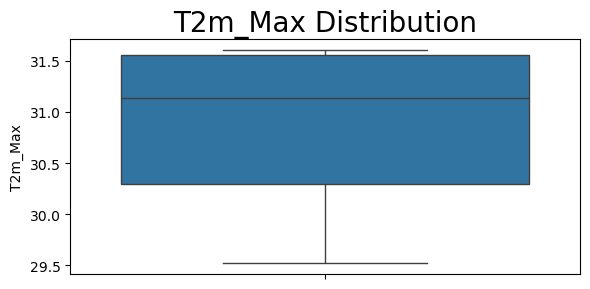

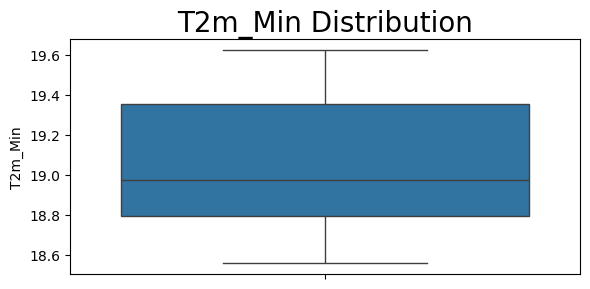

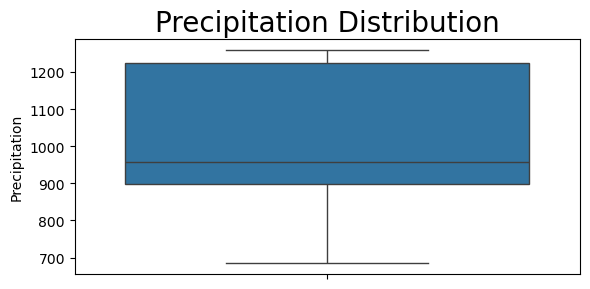

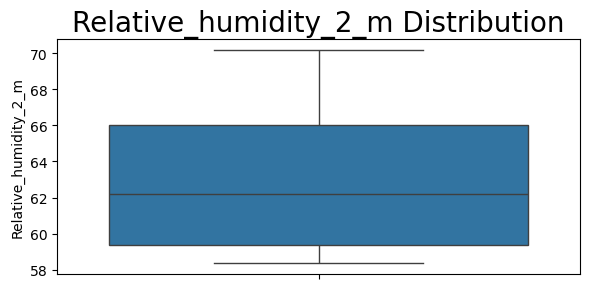

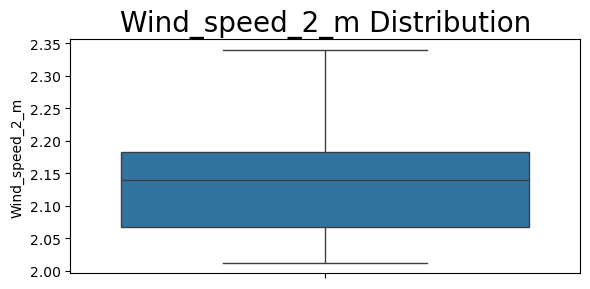

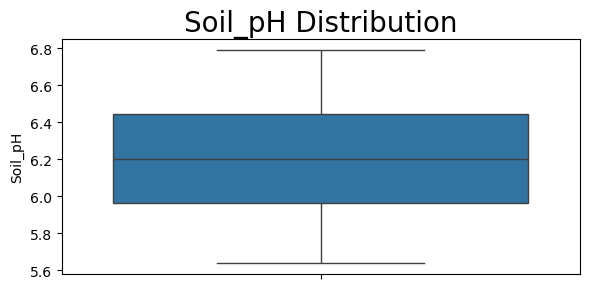

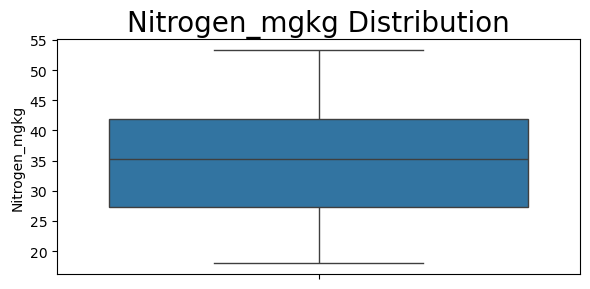

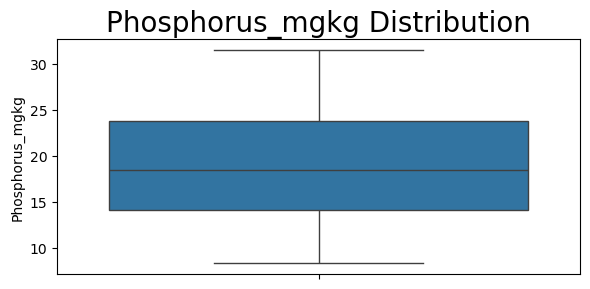

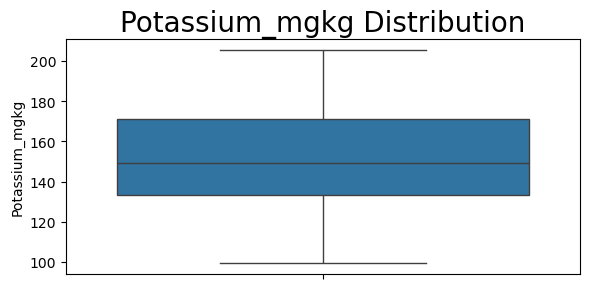

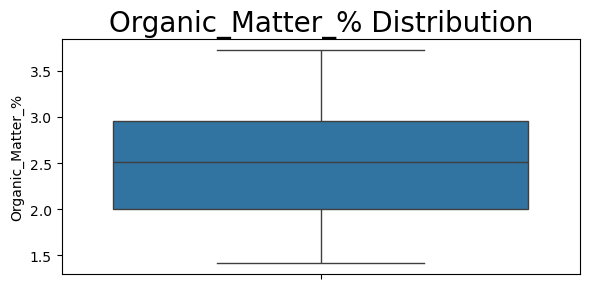

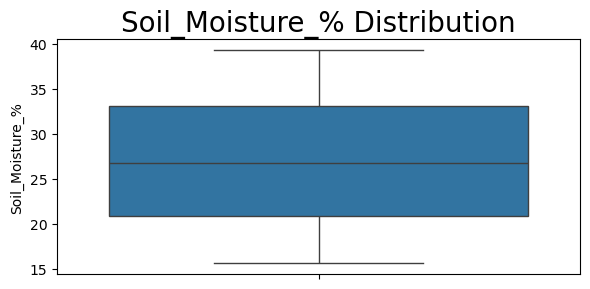

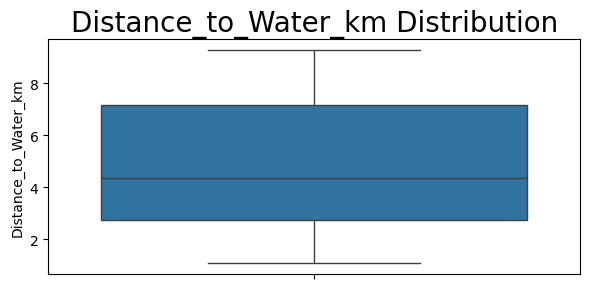

In [47]:
for col in full_num_cols:
    plt.figure(figsize = (6, 3))
    sns.boxplot(full_df[col], orient = 'X')
    plt.title(f'{col} Distribution', fontsize = 20, y = 1.0)
    plt.tight_layout()
    plt.show()

In [48]:
full_df.describe()

,T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m,Soil_pH,Nitrogen_mgkg,Phosphorus_mgkg,Potassium_mgkg,Organic_Matter_%,Soil_Moisture_%,Distance_to_Water_km
count,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,30.800878,19.051705,999.420673,62.780251,2.152333,6.207041,35.239097,19.028052,150.468473,2.501789,27.042708,4.778404
std,0.731747,0.338421,177.503803,4.094505,0.096423,0.316953,9.861979,6.512281,28.983853,0.648556,7.332091,2.630989
min,29.518411,18.557123,684.010000,58.344685,2.011836,5.637014,17.966176,8.314163,99.226061,1.410360,15.574645,1.069838
25%,30.292240,18.792740,897.020000,59.349397,2.067049,5.964033,27.388136,14.131788,133.393209,2.003214,20.847993,2.736709
50%,31.135068,18.972432,958.620000,62.167260,2.139180,6.199597,35.185513,18.453023,149.146825,2.515584,26.685156,4.363782
75%,31.558932,19.352795,1225.150000,65.996093,2.182110,6.445523,41.955117,23.780158,171.107893,2.954568,33.116376,7.163439
max,31.604110,19.624356,1259.250000,70.174932,2.339781,6.790142,53.314588,31.514774,205.468683,3.726589,39.281994,9.279772


In [49]:
numeric_df = full_df.select_dtypes(include = ['number'])
corr_matrix = numeric_df.corr().round(2)
corr_matrix

,T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m,Soil_pH,Nitrogen_mgkg,Phosphorus_mgkg,Potassium_mgkg,Organic_Matter_%,Soil_Moisture_%,Distance_to_Water_km
T2m_Max,1.00,0.79,-0.84,-0.90,-0.06,0.04,0.17,-0.12,0.17,-0.07,-0.01,-0.11
T2m_Min,0.79,1.00,-0.58,-0.66,-0.19,0.15,0.04,-0.10,0.16,-0.13,-0.04,-0.11
Precipitation,-0.84,-0.58,1.00,0.65,0.14,0.02,-0.14,0.16,-0.13,0.02,0.00,0.13
Relative_humidity_2_m,-0.90,-0.66,0.65,1.00,-0.31,-0.03,-0.20,0.13,-0.10,0.07,0.02,0.07
Wind_speed_2_m,-0.06,-0.19,0.14,-0.31,1.00,0.04,0.14,-0.11,-0.17,0.04,-0.07,0.07
Soil_pH,0.04,0.15,0.02,-0.03,0.04,1.00,0.04,0.06,-0.06,-0.00,-0.06,0.01
Nitrogen_mgkg,0.17,0.04,-0.14,-0.20,0.14,0.04,1.00,-0.03,0.02,-0.03,0.19,0.06
Phosphorus_mgkg,-0.12,-0.10,0.16,0.13,-0.11,0.06,-0.03,1.00,0.07,-0.02,0.21,-0.06
Potassium_mgkg,0.17,0.16,-0.13,-0.10,-0.17,-0.06,0.02,0.07,1.00,-0.09,0.05,0.01
Organic_Matter_%,-0.07,-0.13,0.02,0.07,0.04,-0.00,-0.03,-0.02,-0.09,1.00,-0.12,-0.10


In [50]:
corr_matrix.to_csv("correlation_matrix.csv")

In [51]:
crop_counts = full_df["Crop"].value_counts()
crop_counts

Crop
Tomato          7
Yam             7
Ginger          7
Onion           7
Maize           7
Sorghum         7
Rice            7
Ground nut      7
Cowpea          7
Soyabean        7
Cassava         6
Sugar cane      5
Acha            4
Millet          4
Garden egg      4
Okra            4
Sweet potato    2
Cotton          2
Cocoyam         2
Pepper          1
Name: count, dtype: int64

In [52]:
rare_crops = crop_counts[crop_counts < 2].index

In [53]:
# Remove them
full_df = full_df[~full_df['Crop'].isin(rare_crops)]

In [54]:
full_df["Crop"].value_counts()

Crop
Soyabean        7
Tomato          7
Ginger          7
Onion           7
Maize           7
Sorghum         7
Rice            7
Ground nut      7
Cowpea          7
Yam             7
Cassava         6
Sugar cane      5
Acha            4
Millet          4
Garden egg      4
Okra            4
Sweet potato    2
Cotton          2
Cocoyam         2
Name: count, dtype: int64

# DATA PREPROCESSING

In [55]:
scaler = StandardScaler()
for col in full_num_cols:
    full_df[col] = scaler.fit_transform(full_df[[col]])

In [56]:
categorical_columns = full_df.select_dtypes("object").columns

In [57]:
encoder = LabelEncoder()
for col in categorical_columns:
    full_df[col] = encoder.fit_transform(full_df[[col]])

In [58]:
full_df.head()

,Crop,T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m,Soil_pH,Nitrogen_mgkg,Phosphorus_mgkg,Potassium_mgkg,Organic_Matter_%,Soil_Moisture_%,Distance_to_Water_km,Water_Source
0,1,0.673379,-0.759531,-0.603559,-0.8123,0.199007,-1.187997,0.675787,-0.429832,0.321519,-1.198211,0.835995,1.712243,2
1,18,0.673379,-0.759531,-0.603559,-0.8123,0.199007,-0.090101,-0.430854,-0.478689,-0.243667,1.913323,0.788003,-1.198655,0
2,2,0.673379,-0.759531,-0.603559,-0.8123,0.199007,-1.796219,0.203212,-0.154430,0.841627,1.025796,0.269446,-1.235091,1
3,16,0.673379,-0.759531,-0.603559,-0.8123,0.199007,-1.311350,-0.011249,-1.657693,-1.768727,1.390849,-0.154208,1.335583,2
4,8,0.673379,-0.759531,-0.603559,-0.8123,0.199007,-0.334440,0.075026,-1.491434,0.227002,0.793199,-1.489990,-0.066001,2


In [59]:
X = full_df.drop(columns = ["Crop"])
y = full_df["Crop"]

In [60]:
feature_names = X.columns.tolist()
print(feature_names)

['T2m_Max', 'T2m_Min', 'Precipitation', 'Relative_humidity_2_m', 'Wind_speed_2_m', 'Soil_pH', 'Nitrogen_mgkg', 'Phosphorus_mgkg', 'Potassium_mgkg', 'Organic_Matter_%', 'Soil_Moisture_%', 'Distance_to_Water_km', 'Water_Source']


In [61]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, stratify = y, test_size = 0.2, random_state = 42)
print(f"X_train shape : {X_train_val.shape}, X_test shape : {X_test.shape}, y_train shpe : {y_train_val.shape}, y_test shape : {y_test.shape}")

X_train shape : (82, 13), X_test shape : (21, 13), y_train shpe : (82,), y_test shape : (21,)


In [62]:
X_train_val_real = X_train_val.copy()
X_test_real = X_test.copy()

In [63]:
# Convert to DataFrame if they are arrays
X_train_df = pd.DataFrame(X_train_val_real)
y_train_df = pd.DataFrame(y_train_val, columns = ["Crop"])

# Merge horizontally (column-wise)
train_merged = pd.concat([X_train_df, y_train_df], axis = 1)

In [64]:
train_merged.head()

,T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m,Soil_pH,Nitrogen_mgkg,Phosphorus_mgkg,Potassium_mgkg,Organic_Matter_%,Soil_Moisture_%,Distance_to_Water_km,Water_Source,Crop
64,0.470144,0.367225,-0.580953,-1.084870,1.950265,-1.288099,1.049223,0.070864,0.835174,-1.683011,1.203576,-0.566293,2,4
76,-0.688522,-0.226487,0.182603,0.784037,-0.908114,-1.059610,0.365424,-1.657693,-0.255916,-1.051807,1.113487,-1.300962,1,13
19,-0.590713,-0.366299,1.469465,0.247406,-0.152140,-0.502459,-0.557132,-1.023920,-0.511296,-0.327598,-0.014483,-0.381961,2,13
81,-0.688522,-0.226487,0.182603,0.784037,-0.908114,0.293682,0.655029,-0.509056,-1.162229,0.209730,1.209625,-0.997899,1,14
93,-1.752332,-1.458471,1.274312,1.804746,0.297783,-0.217197,-1.073751,1.915557,0.093285,1.913323,-0.360215,1.712243,2,9


# DATA AUGUMENTATION

In [65]:
ctgan = CTGAN(embedding_dim = 128, generator_dim = (256, 256), 
              discriminator_dim = (256, 256), generator_lr = 0.0002,
              discriminator_lr = 0.0002, epochs = 300,
              batch_size = 500, pac = 10, verbose = False)
ctgan.fit(train_merged)
synthetic_data = ctgan.sample(1000) #Generate 1000 samples

In [66]:
train_aug = pd.concat([train_merged, synthetic_data], ignore_index = True)

In [67]:
train_aug.head()

,T2m_Max,T2m_Min,Precipitation,Relative_humidity_2_m,Wind_speed_2_m,Soil_pH,Nitrogen_mgkg,Phosphorus_mgkg,Potassium_mgkg,Organic_Matter_%,Soil_Moisture_%,Distance_to_Water_km,Water_Source,Crop
0,0.470144,0.367225,-0.580953,-1.084870,1.950265,-1.288099,1.049223,0.070864,0.835174,-1.683011,1.203576,-0.566293,2,4
1,-0.688522,-0.226487,0.182603,0.784037,-0.908114,-1.059610,0.365424,-1.657693,-0.255916,-1.051807,1.113487,-1.300962,1,13
2,-0.590713,-0.366299,1.469465,0.247406,-0.152140,-0.502459,-0.557132,-1.023920,-0.511296,-0.327598,-0.014483,-0.381961,2,13
3,-0.688522,-0.226487,0.182603,0.784037,-0.908114,0.293682,0.655029,-0.509056,-1.162229,0.209730,1.209625,-0.997899,1,14
4,-1.752332,-1.458471,1.274312,1.804746,0.297783,-0.217197,-1.073751,1.915557,0.093285,1.913323,-0.360215,1.712243,2,9


In [68]:
# Adding a bit noise to numerical features
noise_level = 0.02
numeric_col = ['T2m_Max', 'T2m_Min', 'Precipitation', 'Relative_humidity_2_m',
       'Wind_speed_2_m', 'Soil_pH', 'Nitrogen_mgkg', 'Phosphorus_mgkg',
       'Potassium_mgkg', 'Organic_Matter_%', 'Soil_Moisture_%',
       'Distance_to_Water_km']
train_aug[numeric_col] = train_aug[numeric_col] * (1 +  np.random.normal(0, noise_level, train_aug[numeric_col].shape))

In [69]:
def evaluate_ctgan(real_data, synthetic_data, numeric_col):
    
    evaluation_table = []

    for col in numeric_col:
        row = {
            "Feature": col,
            "Real Mean": real_data[col].mean(),
            "Synthetic Mean": synthetic_data[col].mean(),
            "Real Std": real_data[col].std(),
            "Synthetic Std": synthetic_data[col].std()
        }
        evaluation_table.append(row)

    return pd.DataFrame(evaluation_table)


In [70]:
# Define numeric columns
numeric_cols =['T2m_Max', 'T2m_Min', 'Precipitation', 'Relative_humidity_2_m',
       'Wind_speed_2_m', 'Soil_pH', 'Nitrogen_mgkg', 'Phosphorus_mgkg',
       'Potassium_mgkg', 'Organic_Matter_%', 'Soil_Moisture_%',
       'Distance_to_Water_km']

# Generate table
ctgan_eval_df = evaluate_ctgan(train_merged[numeric_cols], synthetic_data[numeric_cols],
    numeric_cols)

In [71]:
ctgan_eval_df

,Feature,Real Mean,Synthetic Mean,Real Std,Synthetic Std
0,T2m_Max,0.008371,-0.176251,0.982627,1.088544
1,T2m_Min,-0.053790,-1.206040,0.954090,0.991409
2,Precipitation,-0.038252,-0.692725,1.004591,1.181734
3,Relative_humidity_2_m,-0.024294,1.324174,0.997576,1.355757
4,Wind_speed_2_m,0.038390,1.129872,1.036635,1.333869
5,Soil_pH,0.020444,-0.689123,1.040734,1.271633
6,Nitrogen_mgkg,-0.042470,0.921836,1.011518,1.151396
7,Phosphorus_mgkg,0.009882,-1.040132,0.979263,1.067964
8,Potassium_mgkg,-0.048917,0.705444,1.033433,1.195950
9,Organic_Matter_%,-0.019883,-0.745351,1.021314,1.091851


The table contains four main evaluation columns:

* **Real Mean**: Average value of each feature in the original dataset.
* **Synthetic Mean**:  Average value of each feature in the CTGAN-generated dataset.
* **Real Std (Standard Deviation)**: Spread or variability of the real dataset.
* **Synthetic Std**:  Spread or variability of the synthetic dataset.

## **How to Interpret It**

The goal of CTGAN augmentation is to make synthetic data **statistically similar** to real data.

* If the **real mean and synthetic mean are close**, it means the synthetic data follows the same distribution as the original data.
* If the **standard deviations are also similar**, it indicates that the variability in the synthetic data is realistic.
* Small differences between real and synthetic statistics show good augmentation quality.

## **1. Introduction to CTGAN**

Conditional Tabular GAN (CTGAN) is a deep learning-based data augmentation technique used to generate synthetic tabular data by learning the statistical distribution of an original dataset. In this project, CTGAN was employed to increase the size and diversity of the training dataset for crop prediction without the need to collect additional field data.

## **2. How CTGAN Works**

CTGAN trains two neural networks: the **generator** and the **discriminator**. The generator creates synthetic samples, while the discriminator attempts to distinguish real from synthetic data. During training, these networks compete, improving the generator’s ability to produce realistic samples.


## **3. Key Parameters**

Several parameters were carefully chosen to ensure stable and realistic data generation:

* **embedding_dim**: Controls the internal representation for categorical variables.
* **generator_dim / discriminator_dim**: Defines the architecture of the generator and discriminator networks.
* **learning_rate**: Determines how quickly each network learns.
* **epochs**: Number of training cycles for the GAN.
* **batch_size**: Number of samples processed per training step.
* **pac**: Packs multiple rows together to stabilize training.

These settings ensure that the synthetic data closely mimics the original dataset.


## **4. Gaussian Noise Augmentation**

After CTGAN augmentation, **Gaussian noise** was applied to numerical features such as temperature, rainfall, humidity, and wind speed. This introduces small, random variations that simulate natural environmental fluctuations and enhances the neural network’s ability to generalize.


## **5. Summary**

By combining CTGAN-generated synthetic data with Gaussian noise, a **larger, more diverse, and robust training dataset** was created. This augmented dataset improves the predictive performance of the neural network model for crop selection in the study area.
